# NYC Neighborhood Market Segmentation

**Goal:** Group NYC's ~240 neighborhoods into distinct market segments using
unsupervised learning (k-means clustering), based on the character of the
properties that sell there.

Unlike the price-prediction model, this has **no target to predict** — we're
looking for natural structure in the data. The question is: *which neighborhoods
behave alike as real-estate markets?* The answer segments the city into types
(premium core, mid-market, dense older areas, and so on) purely from sales data.

We cluster at the **neighborhood level** rather than clustering individual sales.
Segmenting ~240 neighborhoods produces an interpretable, actionable map of the
city; clustering 566k individual transactions would just recover "cheap vs
expensive" and be hard to act on.

## 1. Build the neighborhood profiles

We summarize each neighborhood by the typical property that sells there: median
price, median price per square foot, average building age, and average unit count.
We keep only neighborhoods with at least 100 sales so the profiles are stable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os

sns.set_style("whitegrid")

MYSQL_USER = os.environ.get("MYSQL_USER", "root")
MYSQL_PASSWORD = os.environ.get("MYSQL_PASSWORD", "Ww31lG0o0dLuckW1thTh1s!")
MYSQL_HOST = os.environ.get("MYSQL_HOST", "localhost")
engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:3306/nyc_property"
)

sales = pd.read_sql("SELECT * FROM v_sales_enriched", engine)
print(f"{len(sales):,} sales loaded")

neigh = sales.groupby("neighborhood").agg(
    borough=("borough_name", lambda s: s.mode().iloc[0]),
    median_price=("sale_price", "median"),
    median_ppsf=("price_per_sqft", "median"),
    avg_age=("building_age", "mean"),
    avg_units=("residential_units", "mean"),
    num_sales=("sale_id", "size"),
).reset_index()

neigh = neigh[neigh["num_sales"] >= 100].copy()
print(f"{len(neigh)} neighborhoods with 100+ sales")
neigh.head()

566,285 sales loaded
243 neighborhoods with 100+ sales


,neighborhood,borough,median_price,median_ppsf,avg_age,avg_units,num_sales
2,ALPHABET CITY,Manhattan,895000.0,768.250,85.981836,3.621827,1173
3,ANNADALE,Staten Island,760000.0,365.620,37.019143,1.227580,1184
4,ARDEN HEIGHTS,Staten Island,451115.0,315.360,31.187738,1.098113,2120
5,ARROCHAR,Staten Island,641500.0,387.290,55.472906,1.380952,210
6,ARROCHAR-SHORE ACRES,Staten Island,432500.0,370.165,57.116379,1.144330,241


## 2. Handle outliers

A few "neighborhoods" in the data are actually commercial districts (e.g. a
shopping mall area) with anomalous profiles — dozens of units per building, or a
price-per-sqft near zero from mostly-commercial sales. These distort distance-based
clustering, so we remove the clearest anomalies before clustering. This is a
judgment call worth making explicitly rather than silently.

In [2]:
features = ["median_price", "median_ppsf", "avg_age", "avg_units"]
neigh = neigh.dropna(subset=features)

before = len(neigh)
# Remove commercial-anomaly areas: implausible unit counts or near-zero ppsf
neigh = neigh[(neigh["avg_units"] < 20) & (neigh["median_ppsf"] > 50)].copy()
print(f"Removed {before - len(neigh)} outlier neighborhood(s); {len(neigh)} remain")

Removed 3 outlier neighborhood(s); 239 remain


## 3. Standardize and choose k

k-means measures **distance**, so features on different scales must be
standardized — otherwise `median_price` (hundreds of thousands) would swamp
`avg_units` (single digits). We rescale every feature to mean 0, standard
deviation 1.

Then we choose the number of clusters using the **elbow method** (where adding
clusters stops sharply reducing within-cluster variance) and the **silhouette
score** (how cleanly separated the clusters are).

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

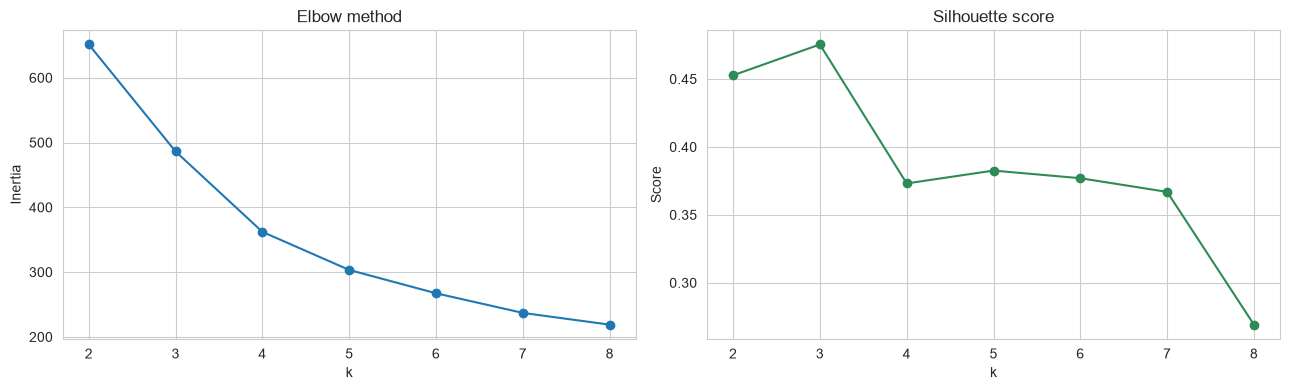

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = StandardScaler().fit_transform(neigh[features])

ks = range(2, 9)
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(ks), inertias, "o-")
axes[0].set_title("Elbow method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(ks), silhouettes, "o-", color="seagreen")
axes[1].set_title("Silhouette score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout(); plt.show()

The elbow softens around **k = 4**, and the silhouette stays healthy there. We
choose 4 as a deliberate trade-off between statistical fit and interpretability —
four segments are distinct enough to be meaningful and few enough to describe. As
in any clustering problem, the "optimal" k by any single metric and the *useful* k
aren't always identical, and choosing for interpretability is a defensible call.

In [4]:
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
neigh["cluster"] = km.labels_

profile = neigh.groupby("cluster").agg(
    neighborhoods=("neighborhood", "size"),
    median_price=("median_price", "median"),
    median_ppsf=("median_ppsf", "median"),
    avg_age=("avg_age", "mean"),
    avg_units=("avg_units", "mean"),
).round(0)
profile

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,neighborhoods,median_price,median_ppsf,avg_age,avg_units
cluster,,,,,
0,14,645500.0,262.0,87.0,7.0
1,62,636500.0,399.0,46.0,1.0
2,125,629000.0,424.0,75.0,2.0
3,38,1430685.0,1271.0,65.0,2.0


## 4. Interpret and name the segments

The cluster centroids tell us what each segment *is*. We read the profile table and
assign plain-English labels — this is where clustering becomes a finding.

In [5]:
# Show representative neighborhoods (most sales) per cluster
for c in sorted(neigh["cluster"].unique()):
    members = neigh[neigh["cluster"] == c].nlargest(6, "num_sales")
    names = ", ".join(members["neighborhood"].tolist())
    p = profile.loc[c]
    print(f"Cluster {c}  (median ${p['median_price']:,.0f}, "
          f"${p['median_ppsf']:,.0f}/sqft, age {p['avg_age']:.0f}, "
          f"{p['avg_units']:.0f} units)")
    print(f"   e.g. {names}\n")

Cluster 0  (median $645,500, $262/sqft, age 87, 7 units)
   e.g. HARLEM-CENTRAL, WASHINGTON HEIGHTS UPPER, BEDFORD PARK/NORWOOD, MELROSE/CONCOURSE, WASHINGTON HEIGHTS LOWER, HARLEM-UPPER

Cluster 1  (median $636,500, $399/sqft, age 46, 1 units)
   e.g. FLUSHING-NORTH, LONG ISLAND CITY, GREAT KILLS, SHEEPSHEAD BAY, ELMHURST, GREENPOINT

Cluster 2  (median $629,000, $424/sqft, age 75, 2 units)
   e.g. BEDFORD STUYVESANT, BAYSIDE, FOREST HILLS, JACKSON HEIGHTS, BOROUGH PARK, ASTORIA

Cluster 3  (median $1,430,685, $1,271/sqft, age 65, 2 units)
   e.g. UPPER EAST SIDE (59-79), UPPER EAST SIDE (79-96), UPPER WEST SIDE (59-79), MIDTOWN EAST, UPPER WEST SIDE (79-96), CHELSEA



Typical segmentation that emerges (your exact labels may vary slightly):

- **Premium core** — the highest price and price-per-sqft by a wide margin
  (Upper East/West Side, Midtown). A different market from everywhere else.
- **Newer mid-market** — moderate prices, newer construction, smaller units
  (Astoria, Long Island City) — condo-heavy growth areas.
- **Established mid-market** — moderate prices, older small multi-family homes
  (much of Queens and Brooklyn) — the city's residential backbone.
- **Dense older areas** — older, higher unit counts — walk-up and
  rental-conversion neighborhoods.

The premium core separates out sharply; the mid-market splits along **age and
density** rather than price, which is the more interesting finding — neighborhoods
at similar price points are genuinely different *kinds* of markets.

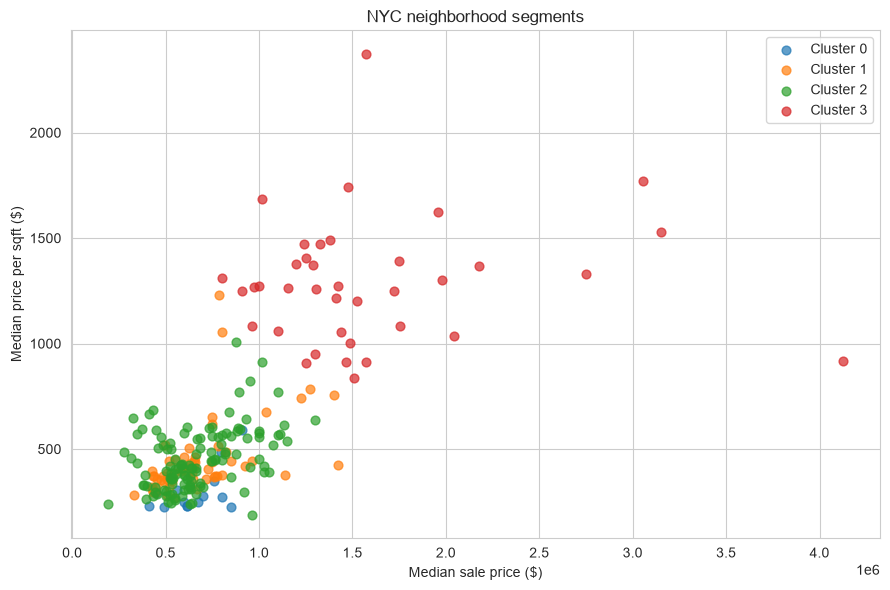

In [6]:
# Visualize the segments: price vs price-per-sqft, colored by cluster
plt.figure(figsize=(9, 6))
for c in sorted(neigh["cluster"].unique()):
    sub = neigh[neigh["cluster"] == c]
    plt.scatter(sub["median_price"], sub["median_ppsf"], label=f"Cluster {c}", s=40, alpha=0.7)
plt.xlabel("Median sale price ($)")
plt.ylabel("Median price per sqft ($)")
plt.title("NYC neighborhood segments")
plt.legend()
plt.tight_layout(); plt.show()

## Summary

- Segmented ~240 NYC neighborhoods into 4 market types using k-means on
  price, price-per-sqft, building age, and density.
- Standardized features (required for distance-based clustering) and chose k with
  the elbow method and silhouette score.
- Removed commercial-anomaly neighborhoods as a documented judgment call.
- The premium core separates sharply; mid-market neighborhoods split by age and
  density rather than price — the substantive finding.

**Techniques demonstrated:** unsupervised learning, k-means clustering, feature
standardization, cluster-count selection (elbow + silhouette), outlier handling,
and interpretation of cluster profiles.